## 3. Stage-by-Stage Explanation

### Stage 1-2: Upscaling

**Problem**: Input tiles are low resolution (e.g., 64×64 pixels), making edge detection unreliable.

**Solution**: We use Lanczos interpolation (cv2.INTER_LANCZOS4) followed by unsharp masking to upscale tiles by 2x while preserving sharp edges.

### Stage 3: Preprocessing

**Problem**: Raw images contain noise that creates false edges.

**Solution**:

- Convert to grayscale (reduces complexity from 3 channels to 1)
- Apply median blur (removes salt-and-pepper noise while preserving edges)

### Stage 4: Binary Segmentation

**Problem**: We need to separate the puzzle piece from the background.

**Solution**:

- Adaptive thresholding (handles varying lighting across the image)
- Morphological opening (removes small noise dots)
- Morphological closing (fills small holes in the piece)

### Stage 5: Contour Extraction

**Problem**: We need the exact boundary of each puzzle piece.

**Solution**: Find all contours in the binary image, keep only the largest one (the piece itself).

### Stage 6: Edge Detection

**Problem**: For matching pieces, we need to detect all edges, not just the boundary.

**Solution**: Canny edge detection with Gaussian blur preprocessing to reduce noise sensitivity.


In [1]:
# Setup
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from upscale import upscale_lanczos_sharp

## 4. Visual Demonstration

Let's demonstrate the pipeline on a single tile to show what each stage produces:


In [2]:
# Load a sample puzzle and extract one tile
puzzle_path = "data/puzzle_4x4/0.jpg"  # Adjust path as needed
puzzle = cv2.imread(puzzle_path)
puzzle_rgb = cv2.cvtColor(puzzle, cv2.COLOR_BGR2RGB)

# Extract first tile (top-left)
h, w = puzzle_rgb.shape[:2]
tile_h, tile_w = h // 4, w // 4
tile = puzzle_rgb[0:tile_h, 0:tile_w]

print(f"Puzzle size: {w}x{h}")
print(f"Tile size: {tile_w}x{tile_h}")

Puzzle size: 224x224
Tile size: 56x56


In [3]:
# Process through all 6 stages
# Stage 1: Original
original = tile.copy()

# Stage 2: Upscaled
upscaled = upscale_lanczos_sharp(tile, scale_factor=2)

# Stage 3: Prep
gray = cv2.cvtColor(upscaled, cv2.COLOR_RGB2GRAY)
prep = cv2.medianBlur(gray, 3)

# Stage 4: Binary
binary = cv2.adaptiveThreshold(
    prep, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2
)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

# Stage 5: Contour
contours, _ = cv2.findContours(
    binary.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
contour_img = np.zeros_like(binary)
if contours:
    main_contour = max(contours, key=cv2.contourArea)
    cv2.drawContours(contour_img, [main_contour], -1, 255, 2)

# Stage 6: Edges
blurred = cv2.GaussianBlur(prep, (5, 5), 1.4)
edges = cv2.Canny(blurred, 40, 50)

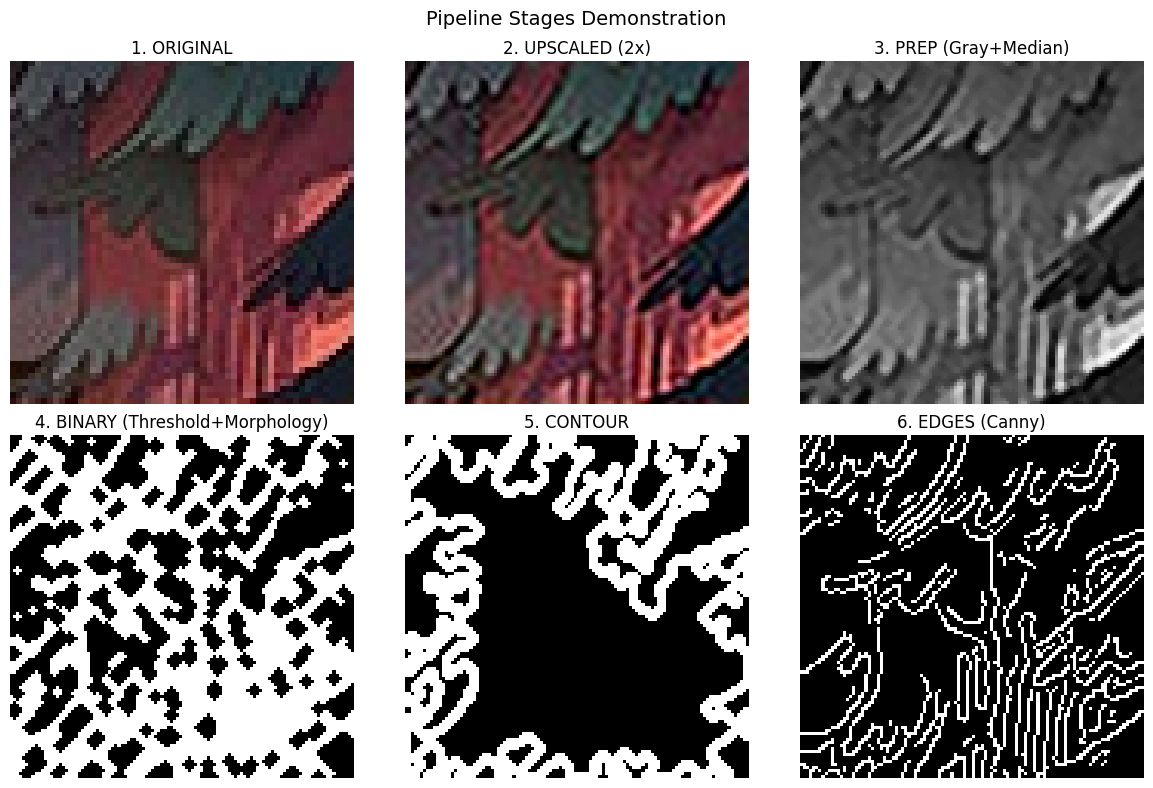

In [4]:
# Visualize all stages
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(original)
axes[0, 0].set_title("1. ORIGINAL")
axes[0, 0].axis("off")

axes[0, 1].imshow(upscaled)
axes[0, 1].set_title("2. UPSCALED (2x)")
axes[0, 1].axis("off")

axes[0, 2].imshow(prep, cmap="gray")
axes[0, 2].set_title("3. PREP (Gray+Median)")
axes[0, 2].axis("off")

axes[1, 0].imshow(binary, cmap="gray")
axes[1, 0].set_title("4. BINARY (Threshold+Morphology)")
axes[1, 0].axis("off")

axes[1, 1].imshow(contour_img, cmap="gray")
axes[1, 1].set_title("5. CONTOUR")
axes[1, 1].axis("off")

axes[1, 2].imshow(edges, cmap="gray")
axes[1, 2].set_title("6. EDGES (Canny)")
axes[1, 2].axis("off")

plt.suptitle("Pipeline Stages Demonstration", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Parameter Testing

We tested different parameters to find optimal values:


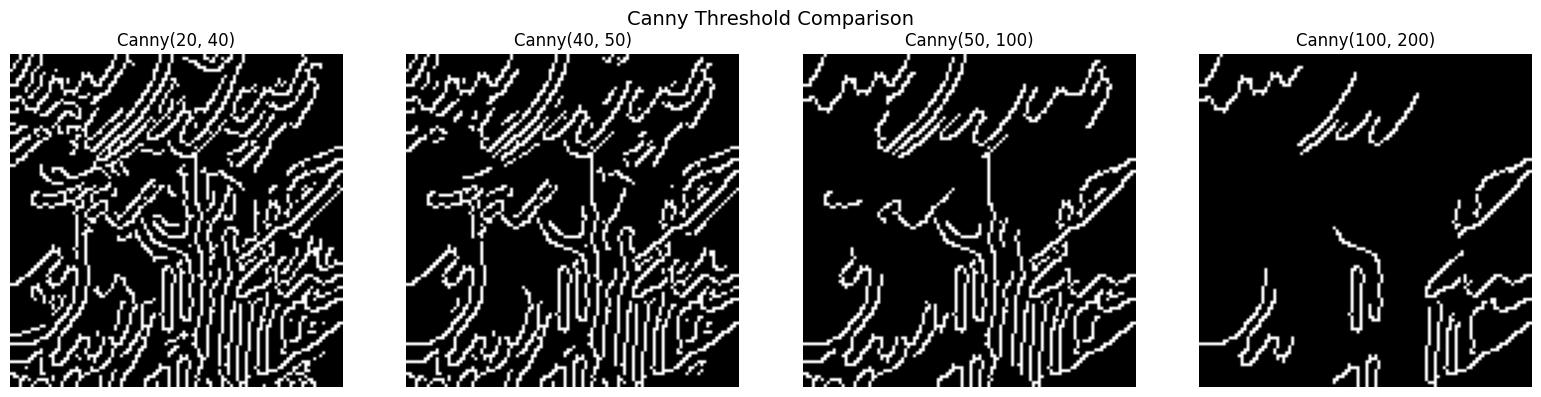

In [5]:
# Test different Canny thresholds
thresholds = [(20, 40), (40, 50), (50, 100), (100, 200)]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (t1, t2) in enumerate(thresholds):
    edges_test = cv2.Canny(blurred, t1, t2)
    axes[i].imshow(edges_test, cmap="gray")
    axes[i].set_title(f"Canny({t1}, {t2})")
    axes[i].axis("off")

plt.suptitle("Canny Threshold Comparison", fontsize=14)
plt.tight_layout()
plt.show()

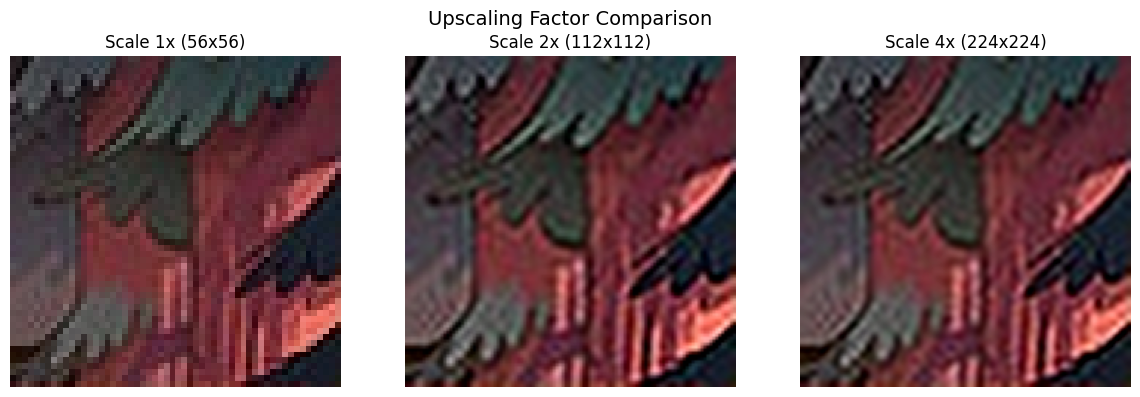

In [6]:
# Test upscaling factors
factors = [1, 2, 4]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, f in enumerate(factors):
    if f == 1:
        up = tile
    else:
        up = upscale_lanczos_sharp(tile, scale_factor=f)
    axes[i].imshow(up)
    axes[i].set_title(f"Scale {f}x ({up.shape[1]}x{up.shape[0]})")
    axes[i].axis("off")

plt.suptitle("Upscaling Factor Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Results and Conclusion

### Chosen Parameters

After testing, we selected these optimal parameters:

| Parameter       | Value  | Reason                                 |
| --------------- | ------ | -------------------------------------- |
| Scale factor    | 2x     | Good balance between quality and speed |
| Median blur     | 3      | Removes noise without losing edges     |
| Threshold block | 11     | Works well for our tile sizes          |
| Morph open      | 1 iter | Removes small noise                    |
| Morph close     | 2 iter | Fills gaps in pieces                   |
| Canny           | 40/50  | Detects edges without too much noise   |

### Output Summary

The pipeline successfully processes puzzles of different sizes:

- **2×2 puzzles**: 4 tiles each
- **4×4 puzzles**: 16 tiles each
- **8×8 puzzles**: 64 tiles each

Each tile produces 6 output images stored in organized folders.

### Next Steps (Phase 2)

With tiles extracted and edges detected, the next phase will:

1. Match pieces based on edge compatibility
2. Use contours to find interlocking shapes
3. Assemble the complete puzzle

---

_Report generated for Jigsaw Puzzle Solver - Phase 1_
